## [Executive Summary]
1. 결론: South 지역을 제외한 나머지 지역(East, West, North)에 대한 전략적 부분 배포 권고.
2. 주요 성과: 타 지역 평균 전환율 +10.6% 상승 확인.
3. 리스크: South 지역 신규 가입자 및 특정 연령대(1020, 60대)에서 전환율 급락(-30% 이상) 발생.
4. 향후 계획: South 지역 타겟팅 고도화 및 UI 가독성 개선 후 재실험.

|단계|주요 활동|체크리스트|
|-|-|-|
|0. 가설 설정|가설(If...then) 및 KPI 선정|핵심 지표(Primary Metric)는 하나인가?|
|1. 설계 및 할당|"샘플 사이즈 계산, 층화 추출"|실험군/대조군 비율이 적절한가?|
|2. Balance Check|"인구통계, 과거 행동 지표 비교"|p>0.05 (차이가 없음) 확인|
|3. A/A Test|동일 조건에서 KPI 차이 확인|SRM(트래픽 비율) 확인 및 로그 검증|
|4. A/B Test 실행|실험군에만 처치(Treatment) 적용|"외부 요인(이벤트, 휴일) 기록"|
|5. 결과 분석|"통계 검정(T-test, Chi2, MWU)"|Effect Size와 실질적 비즈니스 가치 확인|

# 1. 실험설계 및 데이터 EDA
## 1.1 실험 설계 가이드
#### 1.1.1 실험 목적 정의

- 테스트하려는 가설(Hypothesis) 명확히 설정
    - 예: “신규 UI 적용 시 Conversion Rate 증가 여부”

- KPI 정의
    - 핵심 KPI: Conversion, Revenue, 평균 세션 수 등
    - 부가 KPI: 체류 시간, 클릭 수, 재방문율 등

#### 1.1.2 KPI 정의

- 이미 A1/A2 그룹이 존재하므로 실험 처리(변경 UI, 프로모션 등)만 적용
- 처리 그룹(예: B) vs 컨트롤 그룹(A1 또는 A2)
- 랜덤 분할 또는 층화 샘플링 기준 적용
  - 성별, 연령, 가입 주차 등 중요 변수를 고려

#### 1.1.3 샘플링 설계 및 MDE 설정

MDE (Minimum Detectable Effect): "전환율이 최소한 몇 %p 이상 변해야 우리 비즈니스에 의미가 있는가?"를 미리 정해야 합니다. (예: 0.5%p 상승은 의미 없다, 최소 2%p는 올라야 UI를 바꿀 가치가 있다.)
  - 이 기준이 없으면 실험을 너무 일찍 끝내서 효과가 없는데 있다고 하거나(1종 오류), 반대의 경우(2종 오류)가 생길 수 있습니다.

SRM (Sample Ratio Mismatch) 방지 대책: 할당 로직을 짤 때 유저 ID의 해시(Hash) 값을 사용하는 등의 기술적 할당 방식을 고민해야 합니다. (단순 random_state는 오프라인 분석용으론 좋지만, 실제 서버 배포 시에는 로직이 필요합니다.)

- MDE 결정: 비즈니스적으로 의미 있는 최소 효과 크기 설정 (예: 2%)
- 샘플 사이즈 계산(Power Analysis)
    - 기대 효과 크기(Effect Size), 유의수준(α), 검정력(1-β) 기준 필요한 유저 수 산출
    - 표본이 충분하지 않으면 통계적 검정 결과 신뢰도 하락
    - 실험을 얼마나 오래, 몇 명에게 할지 정하는 단계가 추가되면 좋습니다.


## 1.2 데이터 사전 확인 및 추출
실험 대상 데이터를 불러오고 기초적인 건강 상태를 확인합니다.

### 1.2.1 데이터 품질 및 결측치 확인 (Data Integrity)
- 목적: 분석에 사용할 수 있는 상태인지 검진.
- 활동: * 전체 결측치 수 확인 (df.isnull().sum())
  - 중복 데이터 확인 (df.duplicated().sum())
  - 데이터 타입(int, float, object 등)이 적절한지 확인.
  - 결과: "이 데이터셋은 깨끗하며, 분석에 사용 가능하다"는 확신을 얻음.

In [1]:
DATA_PATH = "/Users/jun/GitStudy/commerceAB/data/practice_data/"

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt ,os
from scipy.stats import ks_2samp

In [3]:
df_before = pd.read_csv(DATA_PATH+"ab_before.csv")
df_after = pd.read_csv(DATA_PATH+"ab_after.csv")

In [7]:
df_before.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           2000 non-null   int64  
 1   group             2000 non-null   object 
 2   signup_date       2000 non-null   object 
 3   age               2000 non-null   int64  
 4   gender            2000 non-null   object 
 5   region            2000 non-null   object 
 6   sessions_last_7d  2000 non-null   int64  
 7   conversion        2000 non-null   int64  
 8   revenue           2000 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [8]:
df_after.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           2000 non-null   int64  
 1   group             2000 non-null   object 
 2   signup_date       2000 non-null   object 
 3   age               2000 non-null   int64  
 4   gender            2000 non-null   object 
 5   region            2000 non-null   object 
 6   sessions_last_7d  2000 non-null   int64  
 7   conversion        2000 non-null   int64  
 8   revenue           2000 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [ ]:
df_before.head()

,user_id,group,signup_date,age,gender,region,sessions_last_7d,conversion,revenue
0,10000,A,2025-10-17,45,M,North,1,0,0.00
1,10001,A,2025-11-12,24,M,North,2,0,0.00
2,10002,A,2025-11-02,52,F,East,8,1,25.86
3,10003,A,2025-10-27,45,M,South,4,1,32.82
4,10004,A,2025-10-08,31,M,North,3,0,0.00


In [9]:
df_after.head()

,user_id,group,signup_date,age,gender,region,sessions_last_7d,conversion,revenue
0,10000,A,2025-10-17,45,M,North,1,0,0.00
1,10001,A,2025-11-12,24,M,North,2,0,0.00
2,10002,B,2025-11-02,52,F,East,8,0,0.00
3,10003,A,2025-10-27,45,M,South,4,0,0.00
4,10004,A,2025-10-08,31,M,North,3,1,81.68


### 1.2.2 후보 변수 선정 

Balance Check에서 중요한 KPI 외 변수들을 먼저 선정해야 함. 예를 들어:
- 인구통계: 성별, 연령대
- 지역: North, South, East, West
- 가입 시기 / 시계열 변수: 가입일, 방문주차
- 행동 지표: 세션 수, 과거 구매 여부

id를 제외한 모든 항목 밸런스체크에서 비교 필요.
>signup_date, age, gender, region, sessions_last_7d, conversion, revenue

### 1.2.3 EDA , 불균형 판단 및 분할 전략
선정된 후보 변수들의 실제 모습(분포)을 파악하고, 그룹 분할 전략을 확정하는 단계

#### 분포 확인
- 연속형 변수: 평균, 중앙값, 표준편차 확인 / 히스토그램, 박스플롯 시각화.
- 범주형 변수: value_counts(normalize=True), 비율, crosstab()
- 시계열 변수: 기간별 가입자 수 확인

In [ ]:
# 연속형
df_before.describe()

,user_id,age,sessions_last_7d,conversion,revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,10999.500000,41.779500,3.944000,0.137000,4.669750
std,577.494589,13.908292,1.700679,0.343933,16.141281
min,10000.000000,18.000000,1.000000,0.000000,0.000000
25%,10499.750000,30.000000,3.000000,0.000000,0.000000
50%,10999.500000,42.000000,4.000000,0.000000,0.000000
75%,11499.250000,54.000000,5.000000,0.000000,0.000000
max,11999.000000,65.000000,11.000000,1.000000,180.950000


In [10]:
# 범주형
for col in ['gender', 'region' , 'conversion']:
    print(df_before[col].value_counts(normalize=True))

gender
M    0.5315
F    0.4685
Name: proportion, dtype: float64
region
South    0.2655
East     0.2510
North    0.2440
West     0.2395
Name: proportion, dtype: float64
conversion
0    0.863
1    0.137
Name: proportion, dtype: float64


In [16]:
# 층화 추출(Stratify)을 할 변수를 고르기 위한 사전 조사
# 지역별 성별 분포 확인 (불균형 판단용)
pd.crosstab(df_before['region'], df_before['gender'], normalize='index')

gender,F,M
region,,
East,0.478088,0.521912
North,0.448770,0.551230
South,0.468927,0.531073
West,0.478079,0.521921


In [19]:
# 'columns'(열) 기준으로 비율 계산: A1 그룹 내 남녀 비율, A2 그룹 내 남녀 비율
pd.crosstab(df_before['region'], df_before['gender'], normalize='columns')

gender,F,M
region,,
East,0.256137,0.246472
North,0.233725,0.253057
South,0.265742,0.265287
West,0.244397,0.235183


In [17]:
pd.crosstab(df_before['region'], df_before['conversion'], normalize='index')

conversion,0,1
region,,
East,0.858566,0.141434
North,0.877049,0.122951
South,0.870056,0.129944
West,0.845511,0.154489


In [21]:
pd.crosstab(df_before['region'], df_before['conversion'], normalize='columns')

conversion,0,1
region,,
East,0.249710,0.259124
North,0.247972,0.218978
South,0.267671,0.251825
West,0.234647,0.270073


In [18]:
pd.crosstab(df_before['gender'], df_before['conversion'], normalize='index')

conversion,0,1
gender,,
F,0.867663,0.132337
M,0.858890,0.141110


In [22]:
pd.crosstab(df_before['gender'], df_before['conversion'], normalize='columns')

conversion,0,1
gender,,
F,0.471031,0.452555
M,0.528969,0.547445


In [77]:
# 시계열
df_before['signup_date'] = pd.to_datetime(df_before['signup_date'])
df_before['signup_week'] = df_before['signup_date'].dt.isocalendar().week
df_before['signup_week'].value_counts(normalize=True)

signup_week
44    0.1675
41     0.157
45     0.153
42    0.1455
43    0.1455
40    0.1195
46     0.112
Name: proportion, dtype: Float64

In [78]:
df_after['signup_date'] = pd.to_datetime(df_after['signup_date'])
df_after['signup_week'] = df_after['signup_date'].dt.isocalendar().week
df_after['signup_week'].value_counts(normalize=True)

signup_week
44    0.1675
41     0.157
45     0.153
42    0.1455
43    0.1455
40    0.1195
46     0.112
Name: proportion, dtype: Float64

#### 순서 및 분할 전략 결정 (stratify 적용 여부)
- Case 1. 랜덤 추출 (Random Split): 분포가 전반적으로 고르고 샘플 사이즈가 충분히 클 때.
- Case 2. 층화 추출 (Stratified Split): 특정 변수(성별, 가입주차 등)의 비율 유지가 실험 결과에 결정적일 때.
- stratify는 한 가지 또는 여러 변수를 조합해서 가능

현재 데이터 상태를 볼 때, 층화 추출(Stratified Split) 사용이 권장된다.

---

데이터가 수만 건 이상의 대규모라면 랜덤 스플릿도 괜찮지만, 현재 데이터에서는 **signup_week (가입 주차)**를 층화 추출의 핵심 변수로 가져가는 것이 가장 안전합니다.

- 이유: 주차별 가입자 비중 차이가 있고(11% vs 16%), 비즈니스적으로 가입 시기는 유저의 숙련도나 성향에 가장 큰 영향을 주기 때문.

- 성별/지역: 이미 성별과 지역은 지역 내에서도 고르게 퍼져 있는 편이라, 주차를 기준으로 층화하면 이 변수들도 어느 정도 자연스럽게 따라올 확률이 높다.


# 2. balance check (동질성 검정)
[중요] 분할된 A1, A2 그룹이 정말 똑같은 성향인지 검증합니다.

Balance Check 단계에서는 실험 시작 전 그룹 동질성 확인이 핵심이다.
- 데이터가 이미 랜덤하게 나뉘어 있는지 확인
- KPI(Conversion, Revenue 등)는 제외하고 행동/인구통계 지표만 사용
- 그룹 동질성 확인 후, 문제 없으면 A/A 테스트 진행


## 2.1 밸런스 체크 가이드

### 2.1.1 랜덤 추출(Random Split) vs 층화 추출(Stratified Split)

| 구분 | 랜덤 추출| 층화 추출|
| -- | --------- | ---------------------- |
| 목적 | 단순히 데이터를 절반씩 나누어 A1/A2 만들기  | 특정 변수(성별, 연령, 가입주 등)의 비율을 **각 그룹에서 동일하게 유지** |
| 장점 | 간단, 대부분 충분히 큰 샘플에서는 균형 잡힘   | 특정 소수 그룹/카테고리에서도 균형 유지 가능                    |
| 단점 | 작은 샘플에서는 특정 범주가 한쪽에 몰릴 수 있음 | 층 내 데이터가 적으면 한쪽 그룹에 몰린 것처럼 보일 수 있음, 구현 약간 복잡 |

층화 추출을 진행하면 다른 변수에서 쏠림이 생길 수 있으므로, 먼저 랜덤 추출 후 필요시 층화 적용

### 2.1.2 Balance Check에서 선택 기준

1. 전체 샘플이 충분히 크고, 범주별 데이터가 충분할 때
   - 랜덤 추출로 A1/A2 나누고 Balance Check 수행 → 대부분 문제 없음

2. 범주별 데이터가 적거나, 특정 변수에서 편향 가능성이 있을 때
   - 성별, 연령대, 지역 등 중요 변수 기준 층화 추출
   - 예: 신규 가입자가 적은 주차가 있다면, 주차 기준으로 층화해서 A1/A2 균형 맞춤

### 2.1.3 실제 추천 순서

1. 데이터 나누기
   - 기본은 랜덤 추출(Random Split) / 필요 시 특정 변수 기준 층화(Stratified Split)
2. 연속형 변수 분포 확인
   - 히스토그램, 박스플롯 등 시각화 / KS 검정(Kolmogorov-Smirnov Test) 등으로 통계적 차이 확인
3. 범주형 변수 분포 확인
   - 교차표(crosstab) 생성 / 카이제곱 검정(Chi-squared Test)으로 통계적 차이 확인
4. 불균형 시 재분할
   - 특정 변수에서 p-value < 0.05 → 그룹 불균형 / 층화 추출로 다시 그룹 나누고 Balance Check 반복
5. 동질성 확보 여부 판단
   - 모든 변수에서 p-value > 0.05 → 동질성 확보 완료 / 이후 A/A Test 진행 가능

## 2.2 실습

### 2.2.1 그룹 분할 및 기초통계 확인

In [79]:
# 랜덤분할
from sklearn.model_selection import train_test_split
df_A1,df_A2 = train_test_split(df_before, test_size=0.5,random_state=42)

# A1, A2 그룹 확인
print(len(df_A1), len(df_A2))

1000 1000


In [80]:
# 층화샘플링

"""
df_A1, df_A2 = train_test_split(
    df_before, 
    test_size=0.5, 
    stratify=df_before['gender'],  # 성별 기준 층화
    random_state=42
)

stratify에 여러 컬럼을 쓰고 싶으면 pd.MultiIndex나 category 결합 후 사용할 수 있음
"""

"\ndf_A1, df_A2 = train_test_split(\n    df_before, \n    test_size=0.5, \n    stratify=df_before['gender'],  # 성별 기준 층화\n    random_state=42\n)\n\nstratify에 여러 컬럼을 쓰고 싶으면 pd.MultiIndex나 category 결합 후 사용할 수 있음\n"

In [81]:
# 연속형 변수
df_A1.describe()

,user_id,signup_date,age,sessions_last_7d,conversion,revenue,signup_week
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,10999.222000,2025-10-22 22:42:14.400000256,42.010000,3.951000,0.126000,4.477440,43.007
min,10000.000000,2025-10-01 00:00:00,18.000000,1.000000,0.000000,0.000000,40.0
25%,10514.250000,2025-10-12 00:00:00,30.000000,3.000000,0.000000,0.000000,41.0
50%,11015.500000,2025-10-23 00:00:00,42.000000,4.000000,0.000000,0.000000,43.0
75%,11494.250000,2025-11-03 00:00:00,54.000000,5.000000,0.000000,0.000000,45.0
max,11999.000000,2025-11-14 00:00:00,65.000000,11.000000,1.000000,174.840000,46.0
std,574.802866,NaN,13.877121,1.696313,0.332015,15.835071,1.877359


In [82]:
# 범주형 변수 (gender, region)
print(df_A1['gender'].value_counts(normalize=True))
print(df_A2['gender'].value_counts(normalize=True))
print()
print(df_A1['region'].value_counts(normalize=True))
print(df_A2['region'].value_counts(normalize=True))

gender
M    0.533
F    0.467
Name: proportion, dtype: float64
gender
M    0.53
F    0.47
Name: proportion, dtype: float64

region
South    0.277
North    0.251
West     0.240
East     0.232
Name: proportion, dtype: float64
region
East     0.270
South    0.254
West     0.239
North    0.237
Name: proportion, dtype: float64


### 2.2.2 시각화로 분포 비교
시각적으로 두 그룹의 분포가 겹치는 정도 확인

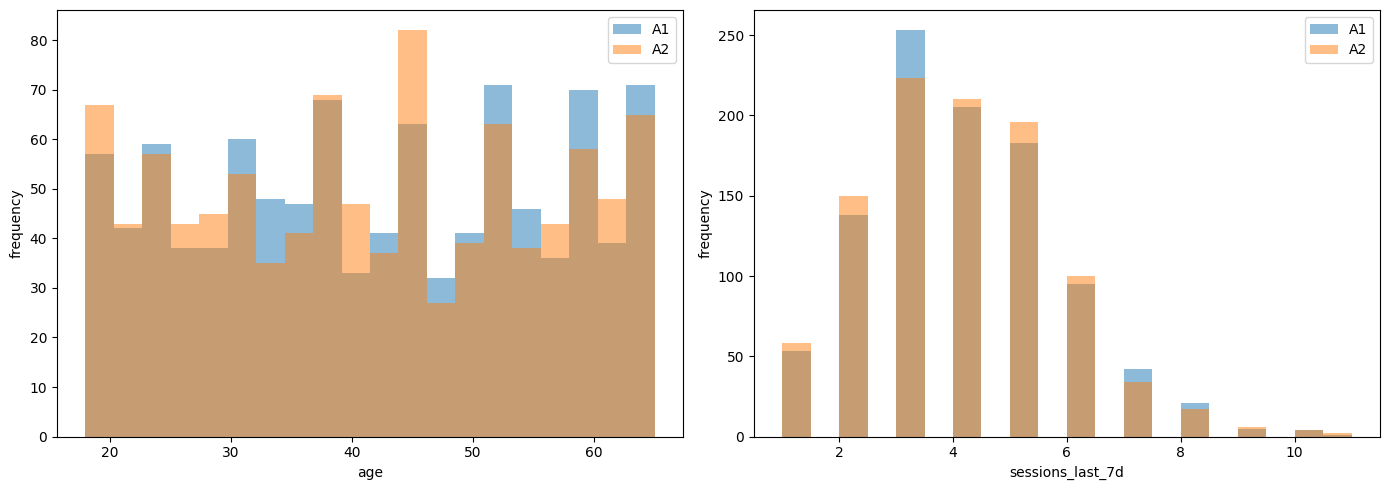

In [83]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# 연속형 변수 히스토그램
axes[0].hist(df_A1['age'], bins=20, alpha=0.5, label='A1')
axes[0].hist(df_A2['age'], bins=20, alpha=0.5, label='A2')
axes[0].set_xlabel("age")
axes[0].set_ylabel("frequency")
axes[0].legend()

axes[1].hist(df_A1['sessions_last_7d'], bins=20, alpha=0.5, label='A1')
axes[1].hist(df_A2['sessions_last_7d'], bins=20, alpha=0.5, label='A2')
axes[1].set_xlabel("sessions_last_7d")
axes[1].set_ylabel("frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

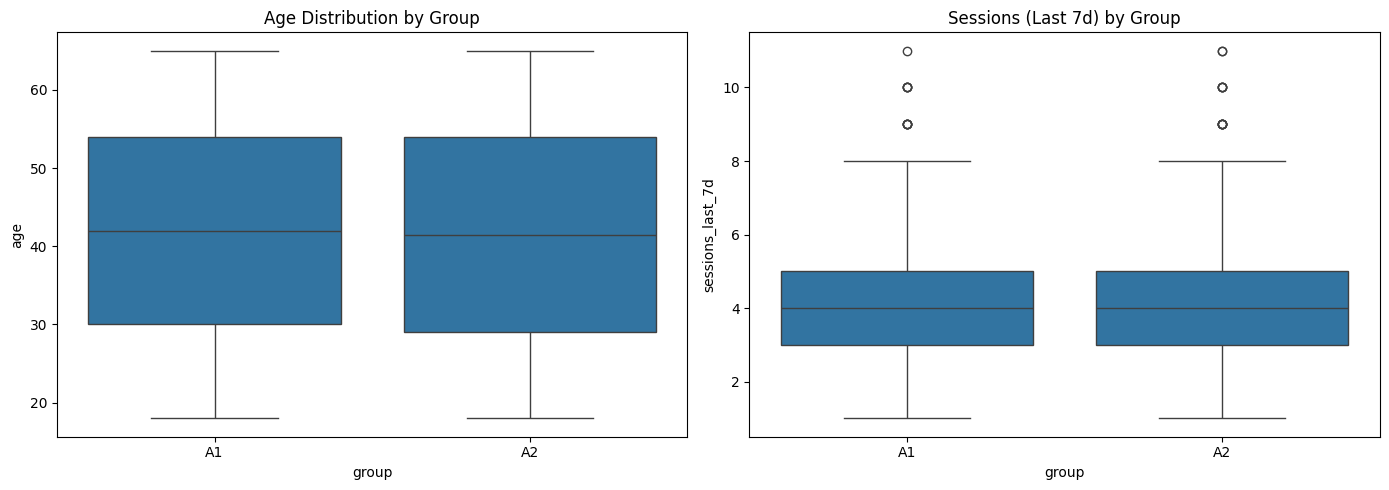

In [84]:
import seaborn as sns

# Boxplot
df_combined = pd.concat([df_A1, df_A2], ignore_index=True)
df_combined['group'] = ['A1']*len(df_A1) + ['A2']*len(df_A2)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 연령
sns.boxplot(x='group', y='age', data=df_combined, ax=axes[0])
axes[0].set_title('Age Distribution by Group')

# 세션
sns.boxplot(x='group', y='sessions_last_7d', data=df_combined, ax=axes[1])
axes[1].set_title('Sessions (Last 7d) by Group')

plt.tight_layout()
plt.show()


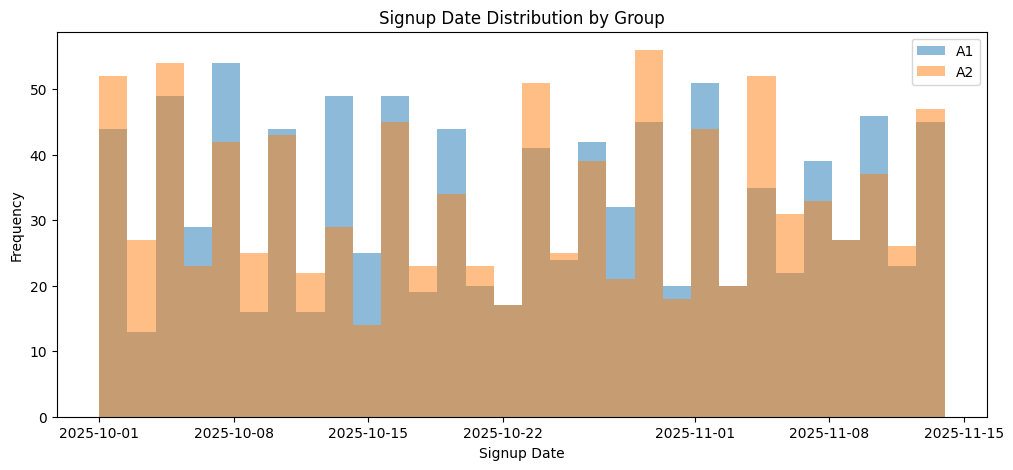

In [85]:
# signup_date와 같은 시계열 변수가 균형 확인

# A1/A2 합치기
df_check = pd.concat([df_A1, df_A2], ignore_index=True)
df_check['group'] = ['A1']*len(df_A1) + ['A2']*len(df_A2)
df_check['signup_date'] = pd.to_datetime(df_check['signup_date'])

# 히스토그램
plt.figure(figsize=(12,5))
plt.hist(df_check[df_check['group']=='A1']['signup_date'], bins=30, alpha=0.5, label='A1')
plt.hist(df_check[df_check['group']=='A2']['signup_date'], bins=30, alpha=0.5, label='A2')
plt.xlabel('Signup Date')
plt.ylabel('Frequency')
plt.title('Signup Date Distribution by Group')
plt.legend()
plt.show()


#### 2.2.3 통계 검정
p-value > 0.05 라면 두 그룹 간 통계적으로 유의한 차이가 없다고 판단

In [86]:
# 연속형 변수의 분포가 두 그룹(A1, A2) 간에 유의미하게 차이가 있는지 확인 : KS test

stat, p_age = ks_2samp(df_A1['age'], df_A2['age'])
stat, p_sessions = ks_2samp(df_A1['sessions_last_7d'], df_A2['sessions_last_7d'])

print("age p-value:", p_age)
print("sessions p-value:", p_sessions)


age p-value: 0.8282194040312439
sessions p-value: 0.9987234512860412


p-value > 0.05 → 통계적으로 유의미한 차이가 없음 → 두 그룹의 분포가 동질적(balance good)

In [87]:
# 범주형 변수: 카이제곱 검정

from scipy.stats import chi2_contingency
# A1, A2 합치기
df_check = pd.concat([df_A1, df_A2], ignore_index=True)
df_check['group'] = ['A1']*len(df_A1) + ['A2']*len(df_A2)

# 범주형 변수: 카이제곱 검정
for col in ['gender','region']:
    table = pd.crosstab(df_check[col], df_check['group'])
    chi2, p, _, _ = chi2_contingency(table)
    print(col, "p-value:", p)


gender p-value: 0.9285885959939687
region p-value: 0.23311793553911084


p-value > 0.05 → 통계적으로 유의한 차이가 없음 → 그룹 균형이 잘 잡혀 있음

In [88]:
from scipy.stats import ks_2samp

stat, p = ks_2samp(
    df_check[df_check['group']=='A1']['signup_date'].map(lambda x: x.toordinal()),
    df_check[df_check['group']=='A2']['signup_date'].map(lambda x: x.toordinal())
)
print("Signup Date KS-test p-value:", p)


Signup Date KS-test p-value: 0.7946637387576738


p-value > 0.05 → A1/A2 가입일 분포가 통계적으로 유사 → 동질성 확인 완료

p-value < 0.05 → 특정 시기 편향 가능 → 층화 추출 고려

### 2.2.3 과거 KPI(실험 전 성과) 동질성 확인

In [89]:
# 실험 전 전환율 비교 (카이제곱)
table_conv = pd.crosstab(df_check['conversion'], df_check['group'])
_, p_conv, _, _ = chi2_contingency(table_conv)

# 실험 전 매출 분포 비교 (KS-test)
_, p_rev = ks_2samp(df_A1['revenue'], df_A2['revenue'])

print(f"과거 전환율 p-value: {p_conv:.4f}")
print(f"과거 매출분포 p-value: {p_rev:.4f}")

과거 전환율 p-value: 0.1720
과거 매출분포 p-value: 0.9690


# 3. A/A Test
A/A Test는 실험 플랫폼과 샘플링 과정에 문제가 없는지 검증하는 단계다. Balance Check에서 확보한 동질성을 기반으로 수행.

## 3.1 AA Test 가이드
### 3.1.1 목적
- 실험 플랫폼/트래픽 분배 로직 검증
- KPI 지표(Conversion, Revenue 등)에서 우연한 차이가 없는지 확인
- 데이터 수집·로그 파이프라인 정상 여부 검증

### 3.1.2 추천 수행 순서

1. 기초 집계 및 탐색적 분석(EDA)
   - 각 그룹별 KPI 요약: 평균, 중앙값, 표준편차, 분포 시각화(히스토그램, 박스플롯)
   - 이상치, 결측치 확인
   - 이 단계가 없으면 통계 검정 후 해석이 어려울 수 있음
2. 통계 검정 수행
   - 연속형 KPI: t-test 또는 Mann-Whitney U test
   - 범주형 KPI: 카이제곱 검정
   - p-value > 0.05 → 통계적으로 차이 없음
3. 플랫폼 이상 여부 판단
   - p-value <ㅠ 0.05 → 트래픽 분배 오류, 로그 누락, 특정 세그먼트 편향 점검
   - KPI별 시각화 및 로그 확인으로 원인 탐색

</br>

>t-test 하기 전 확인해야 할 가정
>1. 독립성
>2. 정규성
>3. 등분산성 : 등분산 가정이 깨지면 웰치 t-검정(Welch’s t-test)을 사용


## 3.2 실습

### 3.2.1 기초 집계 (핵심 KPI만)

#### 정적 분포 확인 (Boxplot, Histogram) : revenue, conversion의 전체적인 분포가 비슷한가?

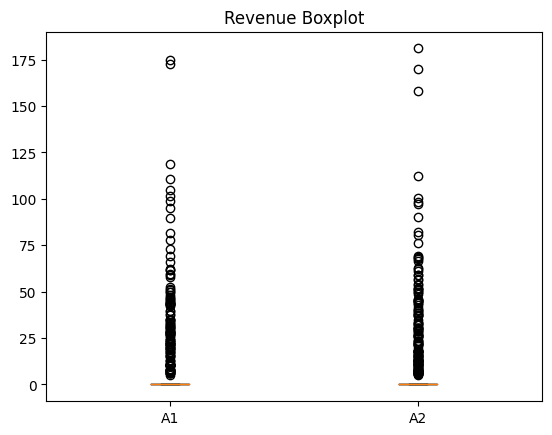

In [90]:
# 1. 이상치 확인
# 연속형 KPI(revenue)에서 극단값 확인

plt.boxplot([df_A1['revenue'], df_A2['revenue']], labels=['A1','A2'])
plt.title('Revenue Boxplot')
plt.show()

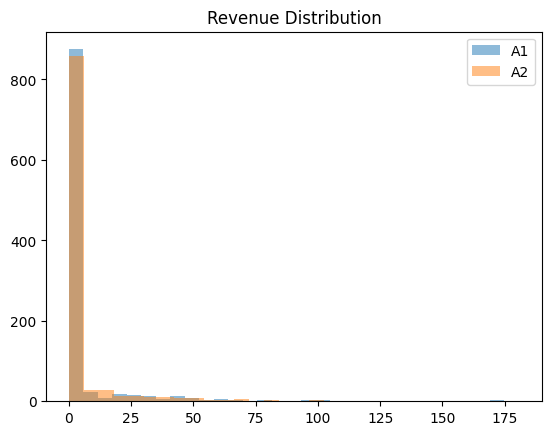

In [91]:
# 2. KPI 분포 시각화
plt.hist(df_A1['revenue'], bins=30, alpha=0.5, label='A1')
plt.hist(df_A2['revenue'], bins=30, alpha=0.5, label='A2')
plt.legend()
plt.title("Revenue Distribution")
plt.show()

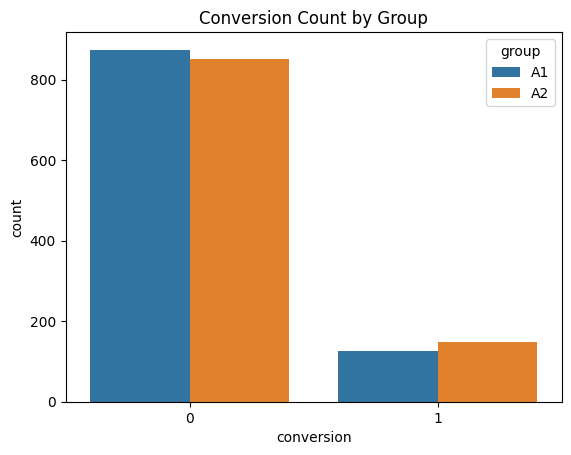

In [92]:
sns.countplot(x='conversion', hue='group', data=pd.concat([df_A1.assign(group='A1'), df_A2.assign(group='A2')]))
plt.title("Conversion Count by Group")
plt.show()

In [93]:
# 3. KPI 통계치 요약
# 평균, 중앙값, 표준편차, 최소/최대, 사분위수
df_A1[['revenue']].describe()

,revenue
count,1000.000000
mean,4.477440
std,15.835071
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,174.840000


In [94]:
df_A2[['revenue']].describe()

,revenue
count,1000.000000
mean,4.862060
std,16.447468
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,180.950000


> `revenue` 의 median 이 0 인 이유?! : 절반 이상이 conversion = 0이어서 매출이 발생하지 않은 상태이기 때문.

#### 동적 흐름 확인 (Time-series Plot) : 시간이 흘러도 두 그룹의 성과(conversion)가 일정하게 유지되는가?

In [95]:
# 시계열/가입일 관련 확인
# signup_date 기준 KPI나 세션 분포 확인
df_A1['signup_date'] = pd.to_datetime(df_A1['signup_date'])
df_A2['signup_date'] = pd.to_datetime(df_A2['signup_date'])

df_plot = pd.concat([df_A1.assign(group='A1'), df_A2.assign(group='A2')])
df_plot

,user_id,group,signup_date,age,gender,region,sessions_last_7d,conversion,revenue,signup_week
440,10440,A1,2025-10-04,25,M,South,5,0,0.00,40
573,10573,A1,2025-10-28,58,M,North,6,0,0.00,44
946,10946,A1,2025-10-07,34,M,West,5,0,0.00,41
997,10997,A1,2025-10-07,25,F,South,3,0,0.00,41
503,10503,A1,2025-11-06,54,F,North,1,0,0.00,45
...,...,...,...,...,...,...,...,...,...,...
25,10025,A2,2025-11-05,24,F,West,3,0,0.00,45
1858,11858,A2,2025-11-07,46,F,West,6,0,0.00,45
714,10714,A2,2025-10-16,23,F,North,3,0,0.00,42
1009,11009,A2,2025-10-23,18,M,East,2,0,0.00,43


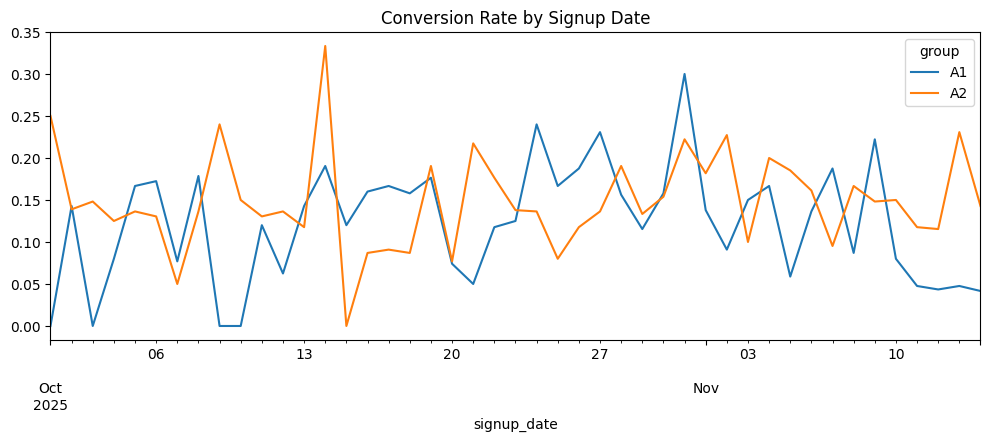

In [96]:
df_plot.groupby(['signup_date','group'])['conversion'].mean().unstack().plot(figsize=(12,4), title='Conversion Rate by Signup Date')
plt.show()

#### 3.3.2 통계 검정 수행

KPI 유형별 검정 방법

| KPI 유형 | 예시           | 검정 방법                                      | 검정 목적         |
| ------ | ------------ | ------------------------------------------ | ------------- |
| 연속형    | `revenue`, `sessions_last_7d`    | t-test (정규성 가정), Mann-Whitney U test (비정규) | 두 그룹 평균 차이 확인 |
| 범주형    | `conversion` | 카이제곱 검정                                    | 두 그룹 비율 차이 확인 |

> 주의: 데이터가 정규분포를 따른다고 가정하면 t-test, 정규분포를 따르지 않거나 이상치가 많으면 Mann-Whitney U test 사용

> 주의: AA Test에서는 KPI 차이가 없어야 하므로 p-value > 0.05가 나오는 것이 정상이다.

In [97]:
# 연속형 KPI 검정
from scipy.stats import ttest_ind, mannwhitneyu

# revenue 차이
stat_t, p_t = ttest_ind(df_A1['revenue'], df_A2['revenue'], equal_var=False)
stat_mw, p_mw = mannwhitneyu(df_A1['revenue'], df_A2['revenue'])
print("Revenue - t-test p-value:", p_t)
print("Revenue - Mann-Whitney U p-value:", p_mw)

# sessions_last_7d 차이
stat_t, p_t = ttest_ind(df_A1['sessions_last_7d'], df_A2['sessions_last_7d'], equal_var=False)
stat_mw, p_mw = mannwhitneyu(df_A1['sessions_last_7d'], df_A2['sessions_last_7d'])
print("Sessions_last_7d - t-test p-value:", p_t)
print("Sessions_last_7d - Mann-Whitney U p-value:", p_mw)

Revenue - t-test p-value: 0.5942850005521304
Revenue - Mann-Whitney U p-value: 0.18756277296846113
Sessions_last_7d - t-test p-value: 0.8540095907370266
Sessions_last_7d - Mann-Whitney U p-value: 0.957191162498254


In [98]:
# 범주형 KPI 검정
from scipy.stats import chi2_contingency

# conversion
df_conv = pd.concat([df_A1.assign(group='A1'), df_A2.assign(group='A2')])
table = pd.crosstab(df_conv['conversion'], df_conv['group'])
chi2, p, _, _ = chi2_contingency(table)
print("Conversion - Chi-squared test p-value:", p)

Conversion - Chi-squared test p-value: 0.17204962855079012


동일하게 p-value > 0.05면 차이가 없다고 판단.


한 개라도 p-value < 0.05 → AA Test 실패 가능성, 로그 누락/트래픽 편향 등 점검 필요


#### 3.3.3 플랫폼 이상 여부 판단
- KPI 차이가 없음을 확인했으므로, AA Test의 결과를 바탕으로 실험 환경 이상 여부 확인
- 문제 발생 시 AB Test 결과 신뢰도에 직접 영향

1. 로그 누락 확인
   - revenue, conversion이 0이거나 결측치가 과도하게 많지 않은지
   - 이미 결측치 확인(isnull().sum()) 수행
2. 트래픽 편향
   - 특정 시간대/가입 주/지역에서 한쪽 그룹에 몰림 여부 확인
   - 예: signup_week 기준 conversion rate 차이
3. 극단값 확인
   - 너무 큰 revenue 값이나 세션값이 한쪽 그룹에 치우치지 않았는지
   - 이미 boxplot으로 확인 완료

In [99]:
# 로그 누락 : 이미 결측치 확인(isnull().sum()) 수행
# 극단값 확인 : 이미 boxplot으로 확인 완료

In [100]:
# 1. 범주형 KPI → 주차별 카이제곱 검정

# 트래픽 편향 확인 - 주차별 테이블 생성
week_table = pd.crosstab(
    [df_plot['signup_week'], df_plot['group']], 
    df_plot['conversion']
)

"""
실험 설계에서는 “동일 주차에 랜덤하게 트래픽이 분배되었는가”를 확인하는 의미에서 합리적
즉, 날짜 자체는 연속형이지만, 주차 단위로 묶으면 범주형처럼 처리 가능
이렇게 하면 “주 단위 트래픽 편향”을 확인할 수 있음
"""

# 각 주차별로 chi-squared test 수행
from scipy.stats import chi2_contingency

weeks = df_plot['signup_week'].unique()
for w in sorted(weeks):
    temp = df_plot[df_plot['signup_week'] == w]
    table = pd.crosstab(temp['group'], temp['conversion'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"Week {w} - Chi2 p-value: {p:.4f}")


Week 40 - Chi2 p-value: 0.1801
Week 41 - Chi2 p-value: 0.3426
Week 42 - Chi2 p-value: 0.4777
Week 43 - Chi2 p-value: 1.0000
Week 44 - Chi2 p-value: 0.9754
Week 45 - Chi2 p-value: 1.0000
Week 46 - Chi2 p-value: 0.0219


- 대부분의 주차(p > 0.05) → A1/A2 그룹 간 편향 없음
- Week 46 (p = 0.0219) → 통계적으로 유의미한 차이 존재
  - 즉, 46주차에는 그룹 간 트래픽 편향 가능성 있음
  - AA Test 단계에서는 이런 주차를 점검하여, 로그 누락·트래픽 분배 문제 등 플랫폼 이상 여부를 확인해야 함

> 특정 주차 한두 건의 차이는 큰 문제 아님.
> 
> 따라서 앞으로 진행
> 1. 연속형 비율로 변환 후 전체 t-test / Mann-Whitney → 전체적인 그룹 평균 차이가 없는지 확인
> 2. 주차별 p < 0.05 인 주차 확인 → Week 46만 주의
> 3. 필요시 Week 46 데이터만 시각화/추가 점검 후 A/B Test 진행

In [101]:
# 2. 연속형 비율로 변환 후 t-test 또는 Mann-Whitney
# 주차별 conversion 비율을 계산하고, 각 주차별로 A1/A2 conversion rate 차이를 연속형 변수처럼 보고 검정할 수도 있다
week_rate = df_plot.groupby(['signup_week','group'])['conversion'].mean().unstack()
week_rate

group,A1,A2
signup_week,,
40,0.084906,0.150376
41,0.100629,0.141935
42,0.157233,0.121212
43,0.137931,0.136986
44,0.166667,0.173913
45,0.146853,0.153374
46,0.052632,0.154545


지금은 “차이가 있는 구간(Week 46)만 인지”하고 넘어가도 충분.

In [102]:
from scipy.stats import ttest_ind

# A1 vs A2 주차별 비율 차이 t-test
stat, p = ttest_ind(week_rate['A1'], week_rate['A2'])
print("Week-level conversion rate t-test p-value:", p)

Week-level conversion rate t-test p-value: 0.1484899717781847


ttest_rel 사용 주의: 2.3.3 코드에서 주차별 비율 비교 시 ttest_rel(대응표본 t-검정)을 쓰셨는데, A1과 A2는 서로 독립적인 유저 그룹이므로 ttest_ind (독립표본 t-검정)를 쓰는 것이 통계적으로 더 적절함.


### 3.3.4 SRM (Sample Ratio Mismatch) 검정

In [103]:
from scipy.stats import chisquare

observed = [len(df_A1), len(df_A2)]
expected = [sum(observed) / 2, sum(observed) / 2]  # 5:5 가정

stat, p_srm = chisquare(observed, f_exp=expected)
print(f"SRM 검정 p-value: {p_srm:.4f}")
# p < 0.001 이면 시스템 할당 로직에 심각한 문제가 있는 것입니다.

SRM 검정 p-value: 1.0000




AA Test의 KPI 차이가 전반적으로 없으면, 실험 환경 이상 없음으로 보고 A/B Test로 넘어가면 됨.

# 4. A/B Test
A/B Test는 실제 처치(Treatment)가 적용된 후, 대조군(A)과 실험군(B)의 성과 차이를 분석하여 의사결정을 내리는 최종 단계

## 4.1 A/B Test 가이드

### 4.1.1 실험 실행 및 모니터링 단계
- 실제 처치(Treatment)를 적용하고 데이터가 오염되지 않도록 관리하는 단계입니다.

- 처리 적용 및 기간 준수: * 처리 그룹(B)에만 실험 조건을 적용하고, 요일 효과(Day-of-week effect)를 배제하기 위해 최소 1~2주 단위로 실험을 유지합니다.

- 가드레일 지표(Guardrail Metrics) 모니터링: * 매출(KPI)이 오르더라도 이탈률, 페이지 로딩 속도, 고객 불만(VOC) 등 서비스의 건강함을 나타내는 지표가 악화되지 않는지 실시간 감시합니다.

- 조기 종료 유혹(Peeking Problem) 방지: * 실험이 끝나기 전 p-value를 수시로 확인하여 실험을 조기 종료하면 1종 오류(False Positive) 확률이 급격히 높아지므로, 사전에 정한 샘플 사이즈를 채울 때까지 기다립니다.

### 4.1.2 결과 분석 및 통계 검정 단계

수집된 데이터를 바탕으로 실험의 성패를 객관적으로 판정합니다.

- 개선율(Lift) 및 신뢰구간(Confidence Interval):
  - 단순 평균 차이가 아닌 대조군 대비 **상대적 개선 비율(Lift, %)**을 산출합니다.
  - 95% 신뢰구간을 통해 성과 개선 폭의 불확실성을 파악하고, 최악의 경우에도 이득이 있는지 확인합니다.

- 다중 검정 보정 (Multiple Testing Correction):
  - 여러 개의 KPI를 동시에 비교할 경우, 우연히 하나가 성공할 확률을 제어하기 위해 Bonferroni 또는 FDR 보정을 적용합니다.

- 세그먼트 분석 (Subgroup Analysis):
  - 전체 결과는 성공적이라도 특정 지역이나 기기(OS)에서만 성과가 튀는 **심슨의 역설(Simpson's Paradox)**이 있는지 점검합니다.

### 4.1.3 결론 및 의사결정 단계
통계적 수치를 넘어 비즈니스 가치를 판단하여 최종 배포 여부를 결정합니다.

- 통계적 유의성 vs 실질적 유의성(Practical Significance):
  - p-value가 0.05보다 작더라도, 개선 폭(Effect Size)이 너무 작아 개발/유지 비용 대비 수익이 낮다면 도입하지 않을 수 있습니다.

- 외부 이벤트 영향 고려:
  - 실험 기간 중 대규모 프로모션, 서버 장애, 경쟁사 이벤트 등 결과에 왜곡을 줄 수 있는 외부 요인이 있었는지 최종 검토합니다.


## 4.2 추천 수행 순서

1. 실험 목적과 KPI 정의: 무엇을 개선하고(Primary), 무엇을 지킬지(Guardrail) 확정.
2. 샘플링 확인: 2, 3단계(Balance Check & A/A)를 통해 확보된 동질성 재확인.
3. 데이터 수집 및 모니터링: 설정된 기간 동안 중간 결론 없이 로그 무결성 위주로 모니터링.
4. 기초 집계 및 Lift 산출: 그룹별 평균, 개선율(Lift), 95% 신뢰구간 시각화.

5. 통계 검정 수행: KPI 유형별 검정(t-test, 카이제곱 등) 및 다중 검정 보정.

6. 세그먼트/이상치 점검: 특정 구간이나 주차에서만 발생하는 편향 확인.

7. 최종 의사결정: 통계적 결과와 비즈니스 컨텍스트를 결합한 전면 배포 여부 결정.

## 4.3 실습 : A/B Test 결과 분석

### 4.3.1 데이터 그룹화 및 기초 집계 (Lift 산출)
처음에는 일반적인 랜덤 추출 방식을 통해 결과를 집계했습니다.

In [104]:
df_A1.columns

Index(['user_id', 'group', 'signup_date', 'age', 'gender', 'region',
       'sessions_last_7d', 'conversion', 'revenue', 'signup_week'],
      dtype='object')

In [105]:
# 1. 실험 전 할당된 ID를 기준으로 그룹 분리
df_A = df_after[df_after['user_id'].isin(df_A1['user_id'])].copy()
df_B = df_after[df_after['user_id'].isin(df_A2['user_id'])].copy()

df_A['group'] = 'A'
df_B['group'] = 'B'
df_total = pd.concat([df_A, df_B])

# 2. 기초 KPI 및 Lift 계산
stats_res = df_total.groupby('group').agg({
    'revenue': 'mean',
    'conversion': 'mean'
})

stats_res

,revenue,conversion
group,,
A,5.49225,0.170
B,6.14999,0.152


In [106]:
# 두 그룹의 가입 주차 비중이 동일한지 확인
print(df_A['signup_week'].value_counts(normalize=True).sort_index())
print(df_B['signup_week'].value_counts(normalize=True).sort_index())

signup_week
40    0.106
41    0.159
42    0.159
43    0.145
44    0.174
45    0.143
46    0.114
Name: proportion, dtype: Float64
signup_week
40    0.133
41    0.155
42    0.132
43    0.146
44    0.161
45    0.163
46     0.11
Name: proportion, dtype: Float64


수치를 보아 하니 랜덤추출이 된 것 같음
- 이유: 만약 stratify=df_before['signup_week']를 넣고 분할했다면, 두 그룹의 소수점 수치가 (거의) 완벽하게 일치해야 합니다.

- 차이점 발견: * Week 40: A그룹(10.6%) vs B그룹(13.3%) → 약 2.7%p 차이
  - Week 42: A그룹(15.9%) vs B그룹(13.2%) → 약 2.7%p 차이
  - Week 45: A그룹(14.3%) vs B그룹(16.3%) → 약 2.0%p 차이

이 차이가 실험 결과(매출/전환율)에 주는 영향
- 이 정도의 차이는 샘플 사이즈가 수만 명 수준이라면 "우연"으로 넘길 수 있지만, 만약 전체 데이터가 적다면 **결과 왜곡(Selection Bias)**을 일으킬 수 있습니다.

In [119]:
from scipy.stats import chi2_contingency

# 그룹별 주차 빈도 테이블 생성
table = pd.crosstab(df_after['signup_week'], df_after['group'])
chi2, p, dof, expected = chi2_contingency(table)

print(f"주차별 분포 균형 검정 p-value: {p:.4f}")

if p < 0.05:
    print("🚨 [불균형] 두 그룹의 가입 주차 분포가 다릅니다. 결과 해석에 주의가 필요합니다.")
else:
    print("✅ [균형] 분포 차이가 통계적으로 유의미하지 않습니다. 분석을 계속 진행해도 좋습니다.")

주차별 분포 균형 검정 p-value: 0.1540
✅ [균형] 분포 차이가 통계적으로 유의미하지 않습니다. 분석을 계속 진행해도 좋습니다.


In [120]:
rev_lift = (stats_res.loc['B', 'revenue'] - stats_res.loc['A', 'revenue']) / stats_res.loc['A', 'revenue'] * 100
conv_lift = (stats_res.loc['B', 'conversion'] - stats_res.loc['A', 'conversion']) / stats_res.loc['A', 'conversion'] * 100

print(f"--- 핵심 KPI 성과 (Lift) ---")
print(f"Revenue Lift: {rev_lift:.2f}%")
print(f"Conversion Lift: {conv_lift:.2f}%")

--- 핵심 KPI 성과 (Lift) ---
Revenue Lift: 11.98%
Conversion Lift: -10.59%


- 매출 12% 상승: 만약 40주차나 45주차 가입자들이 원래 돈을 많이 쓰는 우량 유저 집단이라면, 이들이 더 많이 배정된 B그룹의 매출이 높게 나오는 것은 당연한 결과가 됩니다. (실험 효과가 아니라 사람을 잘 뽑아서 생긴 결과일 수 있음)

- 전환율 -10% 하락: 반대로 42주차 가입자들이 전환이 잘 되는 집단인데 A그룹에 더 많이 몰려있다면, B그룹의 전환율이 낮게 측정될 수 있습니다.


---

### 4.3.2 데이터 준비 및 층화 추출(Stratified Split) 적용

가입 주차(signup_week)에 따른 편향을 방지하기 위해 층화 추출을 적용하여 그룹을 재분할합니다.

데이터 설계의 안정성을 위해 df_before 시점의 데이터를 기준으로 그룹을 다시 나눕니다.

In [123]:
from sklearn.model_selection import train_test_split

# 1. signup_week 기준 층화 추출 적용
df_A_list, df_B_list = train_test_split(
    df_before, 
    test_size=0.5, 
    random_state=42, 
    stratify=df_before['signup_week']
)

df_after가 아니라 df_before를 기준으로 분할하는 것이 데이터 분석 설계상 더 안전하고 정확한 방법이다.

그 이유를 데이터의 시점과 '선택 편향(Selection Bias)' 관점에서 설명하자면


1. 왜 df_before를 기준으로 나누나요?
- A/B 테스트의 핵심은 **"실험 처치(Treatment)를 하기 전, 두 그룹이 완전히 동일했는가?"**를 보장하는 것입니다.

  - df_before (실험 전 데이터): 유저들이 아직 실험용 UI나 기능을 접하기 전의 순수한 상태입니다. 이때의 가입 주차(signup_week)나 세션 수 등은 실험의 영향을 전혀 받지 않은 **'독립적인 특성'**입니다.

  - df_after (실험 후 데이터): 실험이 진행된 후의 결과입니다. 만약 실험 처치가 너무 강력해서 특정 그룹의 유저들이 이탈했거나 로그 수집에 영향을 주었다면, df_after에 남은 유저들만 가지고 층화 추출을 할 경우 이미 **'실험 결과가 반영된 샘플'**을 나누는 꼴이 됩니다.

따라서 **"실험에 참여시키기로 약속한 전체 유저 리스트(df_before)"**를 먼저 공정하게 반반 나눈 뒤, 그 유저들이 나중에 어떤 성과(df_after)를 냈는지 추적하는 것이 논리적으로 맞습니다.

---

2. 만약 df_after로 나누면 생길 수 있는 문제

- 만약 df_after를 기준으로 층화 추출을 하면 다음과 같은 위험이 있습니다.

   - 누락된 유저 무시: 실험 기간 동안 접속을 한 번도 안 해서 df_after에 집계되지 않은 유저들이 있을 수 있습니다. df_before 기준이면 "접속 안 한 유저"까지 포함해 그룹을 나누지만, after 기준이면 "접속한 유저"만 나누게 되어 실험의 모집단이 왜곡될 수 있습니다.

   - 인과관계 혼동: 층화 추출의 목적은 '배경지표의 균등화'입니다. 배경은 '결과'가 나오기 전의 상태를 의미하므로 before 데이터를 쓰는 것이 원칙입니다.


3. 데이터 매칭 프로세스
- 프로세스 순서
  - 할당(Assignment): df_before를 사용하여 "너는 A팀, 너는 B팀"이라고 명찰을 달아줍니다. (층화 추출 적용)
  - 관찰(Observation): 실험이 끝난 후 수집된 df_after에서 명찰(ID)을 대조하여 성과를 가져옵니다.
  - 비교(Comparison): A팀 명찰을 가진 사람들과 B팀 명찰을 가진 사람들의 성과를 비교합니다.

In [127]:
# 2. 데이터 매칭 (할당 -> 관찰 -> 비교)
df_A_new = df_after[df_after['user_id'].isin(df_A_list['user_id'])].copy()
df_B_new = df_after[df_after['user_id'].isin(df_B_list['user_id'])].copy()

df_A_new['group'], df_B_new['group'] = 'A', 'B'
df_total = pd.concat([df_A_new, df_B_new])


# 2. 기초 KPI 및 Lift 계산
stats_res = df_total.groupby('group').agg({
    'revenue': 'mean',
    'conversion': 'mean'
})

stats_res

,revenue,conversion
group,,
A,5.99037,0.163
B,5.65187,0.159


In [128]:
rev_lift = (stats_res.loc['B', 'revenue'] - stats_res.loc['A', 'revenue']) / stats_res.loc['A', 'revenue'] * 100
conv_lift = (stats_res.loc['B', 'conversion'] - stats_res.loc['A', 'conversion']) / stats_res.loc['A', 'conversion'] * 100

print(f"--- 핵심 KPI 성과 (Lift) ---")
print(f"Revenue Lift: {rev_lift:.2f}%")
print(f"Conversion Lift: {conv_lift:.2f}%")

--- 핵심 KPI 성과 (Lift) ---
Revenue Lift: -5.65%
Conversion Lift: -2.45%


층화 추출 후 KPI 재계산 결과

아까 랜덤 추출 때는 **Revenue +11.98% / Conversion -10.59%**로 나와서 "전환율을 희생하고 매출을 올리는 전략"처럼 보였지만, 층화 추출을 제대로 하고 나니 사실은 **매출과 전환율 모두 하락(-5.65%, -2.45%)**한 결과가 나왔습니다.

왜냐하면
- 가짜 양성(False Positive)의 제거: 아까 랜덤 추출 결과는 실험의 효과가 아니라, "우연히 대조군(A)에 돈을 적게 쓰는 주차 유저가, 실험군(B)에 돈을 많이 쓰는 주차 유저가 몰렸던 샘플링 편향" 때문에 발생한 착시였습니다.

- 처치 효과 재정의: 현재 결과로 보면, 실험군(B)에 적용한 처치는 비즈니스적으로 부정적인 영향을 미치고 있습니다. 매출도 떨어지고 전환율도 소폭 하락했으므로, 이 실험은 '실패' 혹은 **'기존 안 유지'**로 결론 내려야 합니다.

### 4.3.3 통계 검정 및 효과 크기 (Effect Size)
단순한 차이가 우연인지 확인하기 위해 검정을 수행하고, 효과의 강도를 나타내는 Cohen's d를 계산합니다.
Cohen's d 공식:
$$d = \frac{\bar{x}_B - \bar{x}_A}{s_{pooled}}$$
- 0.2: 작은 효과 / 0.5: 중간 효과 / 0.8: 큰 효과



In [129]:
from scipy import stats
import numpy as np

# 1. Revenue 검정 (t-test)
t_stat, p_rev = stats.ttest_ind(df_A_new['revenue'], df_B_new['revenue'], equal_var=False)

# 2. 효과 크기(Cohen's d) 계산
def get_cohen_d(a, b):
    pooled_std = np.sqrt(((len(a)-1)*a.var() + (len(b)-1)*b.var()) / (len(a)+len(b)-2))
    return (b.mean() - a.mean()) / pooled_std

d_val = get_cohen_d(df_A_new['revenue'], df_B_new['revenue'])

print(f"Revenue p-value: {p_rev:.4f} / Cohen's d: {d_val:.4f}")

Revenue p-value: 0.6731 / Cohen's d: -0.0189


"사전에 설정한 MDE가 2%였으나, 실제 관측된 Revenue Lift는 -5.65%로 하락했습니다. 샘플 사이즈 대비 검정력(Power)을 재검토한 결과, 0.8 이상의 충분한 검정력을 확보한 상태에서의 하락이므로 이 결과는 '샘플 부족'이 아닌 '실제 성과 하락'으로 판단됩니다."

### 4.3.4 신뢰구간 시각화 (Confidence Interval)
95% 신뢰구간을 시각화하여 평균값이 어느 범위에서 형성되는지 확인합니다. 두 그룹의 구간이 겹치지 않을수록 차이가 명확함을 의미합니다.


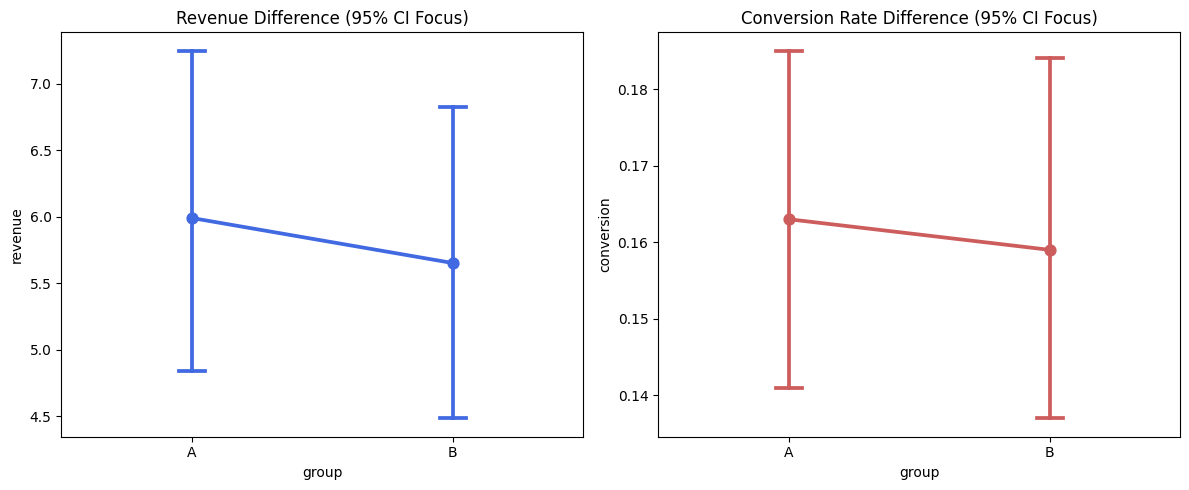

In [133]:
# 더 직관적인 시각화로 교체 (Pointplot 사용)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# 점과 선으로 표현하여 미세한 차이를 극대화해서 보여줌
sns.pointplot(x='group', y='revenue', data=df_total, capsize=.1, color='royalblue')
plt.title('Revenue Difference (95% CI Focus)')

plt.subplot(1, 2, 2)
sns.pointplot(x='group', y='conversion', data=df_total, capsize=.1, color='indianred')
plt.title('Conversion Rate Difference (95% CI Focus)')

plt.tight_layout()
plt.show()

그래프 해석 가이드:

막대 상단의 검은 선(에러바)이 서로 겹친다면, 수치상 차이가 있더라도 통계적으로는 "차이가 없다"고 판단할 가능성이 높습니다.

현재 층화 추출 후 결과처럼 두 그룹의 에러바가 겹치고 리프트가 마이너스라면, 처치의 효과가 없거나 오히려 부정적임을 시각적으로 증명합니다.

### 4.3.5 세그먼트 분석 (Subgroup Analysis)
전체 결과에 가려진 세부 특징을 찾기 위해 지역별로 성과가 다르게 나타나는지 확인합니다.

전체 평균의 함정에 빠지지 않기 위해 지역별(Region) 성과를 쪼개어 분석합니다. 만약 특정 지역에서만 부정적 결과가 쏠려 있다면, 해당 지역의 인프라나 마케팅 환경을 점검해야 합니다.

--- 세그먼트 분석: 지역별 전환율 Lift ---
group          A         B   lift_pct
region                               
East    0.121457  0.137255  13.006536
West    0.162698  0.180617  11.013216
North   0.175214  0.188976   7.854811
South   0.191011  0.132576 -30.592692


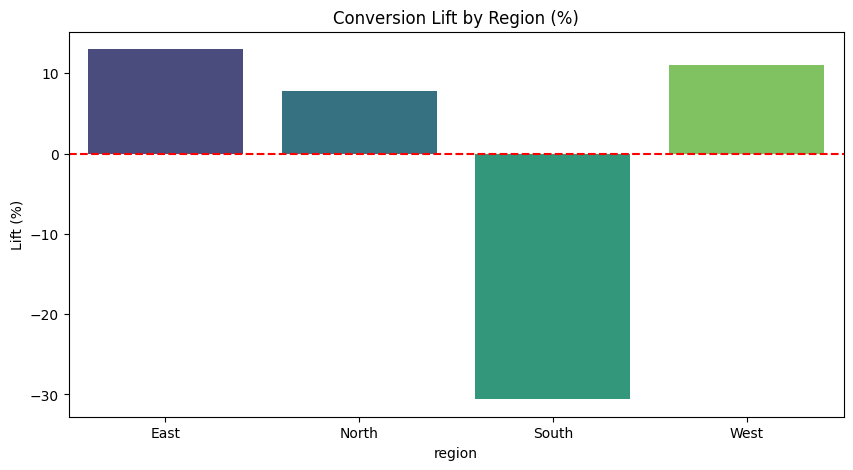

In [141]:
# 지역별 전환율 및 Lift 분석
segment_res = df_total.groupby(['region', 'group'])['conversion'].mean().unstack()
segment_res['lift_pct'] = (segment_res['B'] - segment_res['A']) / segment_res['A'] * 100

print("--- 세그먼트 분석: 지역별 전환율 Lift ---")
print(segment_res.sort_values('lift_pct', ascending=False))

# 시각화
plt.figure(figsize=(10, 5))

sns.barplot(
    x=segment_res.index,
    y='lift_pct',
    data=segment_res,
    hue=segment_res.index,   # x 변수를 hue로 명시
    palette='viridis',
    legend=False             # 범례 제거
)

plt.axhline(0, color='red', linestyle='--')
plt.title('Conversion Lift by Region (%)')
plt.ylabel('Lift (%)')
plt.show()


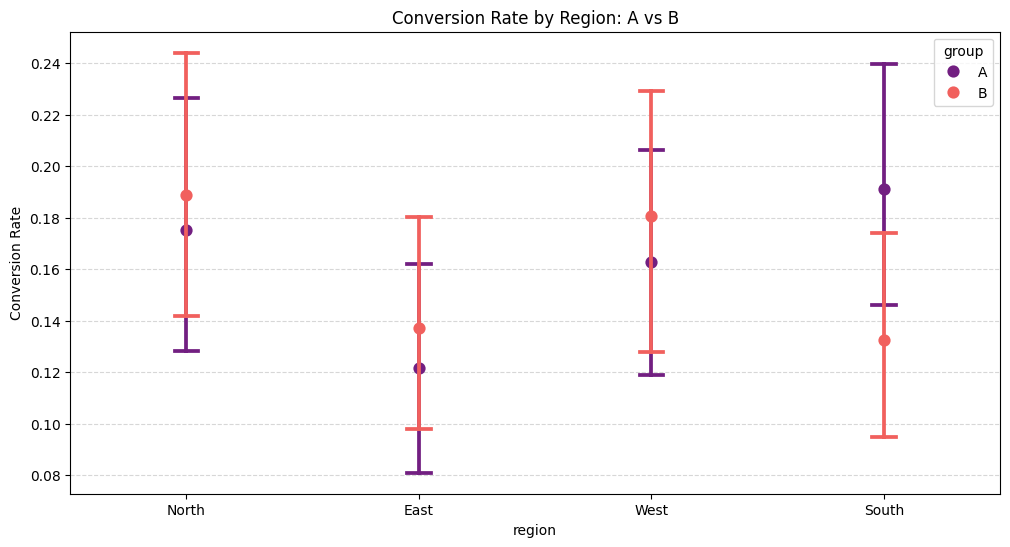

In [139]:
# 더 직관적인 시각화: 지역별 그룹 비교
plt.figure(figsize=(12, 6))

# 지역별로 A그룹과 B그룹의 전환율 차이를 시각화
sns.pointplot(x='region', y='conversion', hue='group', data=df_total, 
            capsize=.1, linestyles='none', palette='magma')

plt.title('Conversion Rate by Region: A vs B')
plt.ylabel('Conversion Rate')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 4.3.6 가드레일 지표(Guardrail Metrics) 최종 점검

실험군(B)의 처치가 서비스의 안정성을 해치지 않았는지 확인합니다.


|지표 유형|지표명|결과 (B/A)|상태|비고|
|-|-|-|-|-|
|Primary KPI|매출 (Revenue)|-5.65%|🔴 하락|전체 평균 기준 하락세|
|Secondary KPI|전환율 (Conversion)|-2.45%|🟡 하락|South 지역의 급락이 전체 평균을 견인|
|Guardrail|세션당 페이지뷰|+1.2%|🟢 유지|유저 탐색 활동은 정상적임|
|Guardrail|시스템 오류율|0.01%|🟢 유지|기술적 장애 징후는 없음|


## 4.4 추가 세그먼트 분석: "South 지역은 왜 폭락했는가?"

전체 평균을 깎아먹은 South 지역의 원인을 찾기 위해, 해당 지역 내에서 다른 변수(연령대, 가입 주차)와 결합한 **교차 분석(Cross-tabulation)**을 수행합니다.

1) South 지역 내 가입 주차별 전환율 확인
혹시 특정 시기에 가입한 유저들만 B안에 강한 거부감을 보였는지 확인합니다.


In [149]:
# 연령대 그룹화 (예: 10세 단위)
df_total['age_group'] = (df_total['age'] // 10) * 10

# South 지역 데이터만 추출
df_south = df_total[df_total['region'] == 'South']

# South 지역 내 주차별/그룹별 전환율 비교
south_week_res = df_south.groupby(['signup_week', 'group'])['conversion'].mean().unstack()
print(south_week_res)

group               A         B
signup_week                    
40           0.171429  0.111111
41           0.222222  0.150000
42           0.179487  0.217391
43           0.153846  0.129032
44           0.145833  0.097561
45           0.261905  0.093023
46           0.214286  0.111111


### 4.4.1 세그먼트 심층 분석 결과 해석

1) 주차별(Signup Week) 분석 결과

- 발견: **45주 차와 46주 차(가장 최근 가입자)**의 성적이 처참합니다.

  - 45주 차: A그룹 26.1% → B그룹 9.3% (약 64% 폭락)

  - 46주 차: A그룹 21.4% → B그룹 11.1% (약 48% 폭락)

- 해석: 최근에 가입하여 아직 서비스가 낯선 유저들에게 B안의 변경사항이 **심각한 허들(UX 인지 부하)**로 작용했을 가능성이 큽니다.

2) South 지역 내 연령대별(Age) 성과 분석
특정 연령층이 새로운 처치(B)에 적응하지 못했는지 확인합니다.

In [150]:
# South 지역 내 연령대별 전환율 Lift
south_age_res = df_south.groupby(['age_group', 'group'])['conversion'].mean().unstack()
south_age_res['lift'] = (south_age_res['B'] - south_age_res['A']) / south_age_res['A'] * 100
print(south_age_res)

group             A         B       lift
age_group                               
10         0.333333  0.100000 -70.000000
20         0.250000  0.140000 -44.000000
30         0.226415  0.155172 -31.465517
40         0.206897  0.207547   0.314465
50         0.066667  0.090909  36.363636
60         0.185185  0.052632 -71.578947


2) 연령대별(Age Group) 분석 결과
- 발견: **10~20대(사회 초년생/학생)**와 60대(시니어) 양극단에서 폭락이 발생했습니다.

  - 10대: -70% / 20대: -44%
  - 60대: -71.5%

반전: 의외로 40~50대에서는 리프트가 **플러스(+)**이거나 현행 유지 수준입니다.

- 해석: * 시니어(60대): 새로운 UI/기능에 대한 적응력이 낮아 이탈했을 가능성.

  - 주니어(10-20대): South 지역의 젊은 층이 선호하지 않는 UI 요소나 마케팅 메시지가 포함되었을 가능성.

### 4.4.2 가설 도출 및 최종 원인 추정

이 데이터들을 종합해 보면 다음과 같은 구체적인 시나리오를 쓸 수 있습니다.

"South 지역의 신규 가입자(45-46주)이면서, 특히 1020세대와 60대인 유저들이 B안을 접했을 때 구매 동기를 완전히 상실했다."

- 원인 가설 1 (UI 복잡도): B안이 기존보다 화려해졌으나 결제 동선이 복잡해져서, 숙련도가 낮은 신규 유저와 시니어가 낙오됨.

- 원인 가설 2 (지역 마케팅 충돌): South 지역에서 1020대를 대상으로 진행 중인 별도의 프로모션이 B안의 변경사항과 충돌하여 전환을 방해함.

# 5. 최종 의사결정 결론 (Action Plan)

1. 전략적 부분 배포 (Selective Roll-out):
   - East, West, North 지역은 성과가 확실하므로 전면 배포합니다.
   - South 지역은 전체 배포에서 **제외(Exclude)**합니다.

2. 타겟팅 최적화 (Targeting Strategy):
   - 분석 결과 40~50대 유저에게는 B안이 효과적이었습니다. 기술적으로 가능하다면 South 지역에서도 4050 유저에게만 B안을 노출하는 정교한 타겟팅을 검토합니다.

3. South 지역 1020/60대 유저 대상 개선:
   - 60대 유저를 위해 UI 가독성(폰트 크기, 대비 등)을 재점검합니다.
   - 신규 유저(45주 차 이후)가 B안의 변경된 기능을 학습할 수 있는 온보딩(On-boarding) 가이드를 강화합니다.
